<a href="https://colab.research.google.com/github/arzss-code/pengolahan-citra/blob/main/jobsheet_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Jobsheet 03 - Perbaikan Citra Dalam Domain Spasial

Atsiila Arya Nabiih - 4.33.23.1.04

### Praktikum 1. Transormasi Kurva (Citra Negatif)

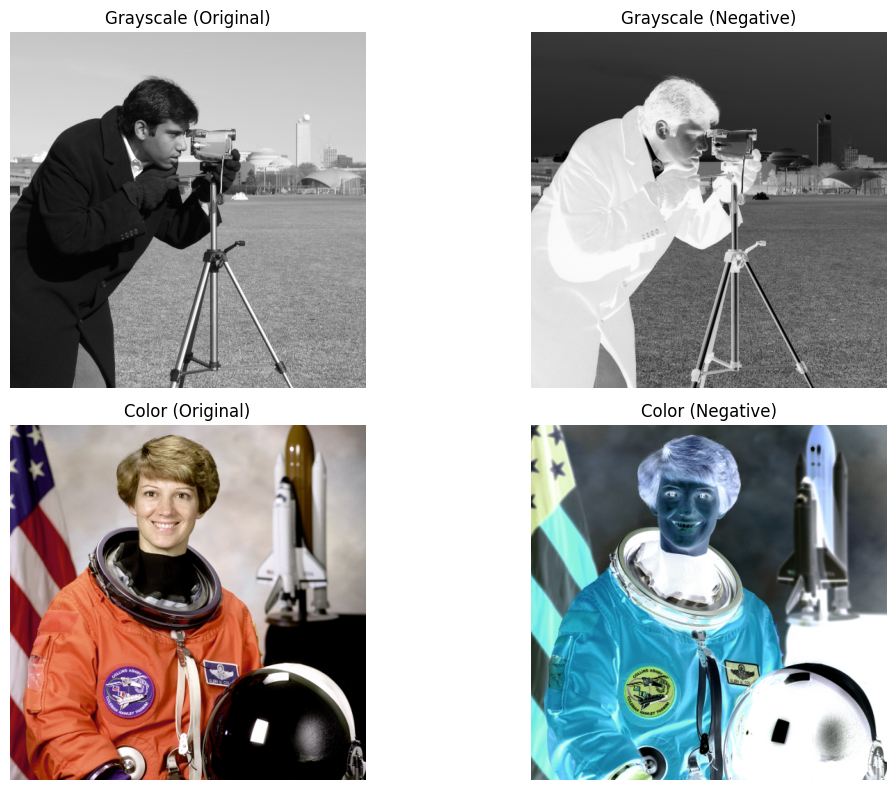

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float

# ===================
# 1. TRANSFORMASI NEGATIF CITRA GRAYSCALE
# ===================
image_gray_uint8 = data.camera()  # Citra grayscale (512x512, 0..255)
image_gray_float = img_as_float(image_gray_uint8)  # Konversi ke float [0..1]

negative_gray = 1.0 - image_gray_float  # Inversi intensitas: output = 1 - input

# ===================
# 2. TRANSFORMASI NEGATIF CITRA BERWARNA
# ===================
image_color_uint8 = data.astronaut()  # Citra berwarna (512x512x3, 0..255)
image_color_float = img_as_float(image_color_uint8)  # Konversi ke float [0..1]

negative_color = 1.0 - image_color_float  # Inversi intensitas tiap kanal RGB

# ===================
# 3. PLOTTING HASIL
# ===================
fig, axes = plt.subplots(2, 2, figsize=(12, 8))

# Baris 1: Grayscale (original, negative)
axes[0, 0].imshow(image_gray_float, cmap='gray')
axes[0, 0].set_title("Grayscale (Original)")
axes[0, 0].axis('off')

axes[0, 1].imshow(negative_gray, cmap='gray')
axes[0, 1].set_title("Grayscale (Negative)")
axes[0, 1].axis('off')

# Baris 2: RGB (original, negative)
axes[1, 0].imshow(image_color_float)
axes[1, 0].set_title("Color (Original)")
axes[1, 0].axis('off')

axes[1, 1].imshow(negative_color)
axes[1, 1].set_title("Color (Negative)")
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()


### Praktikum 2. Histogram dan Ekualisasi Histogram

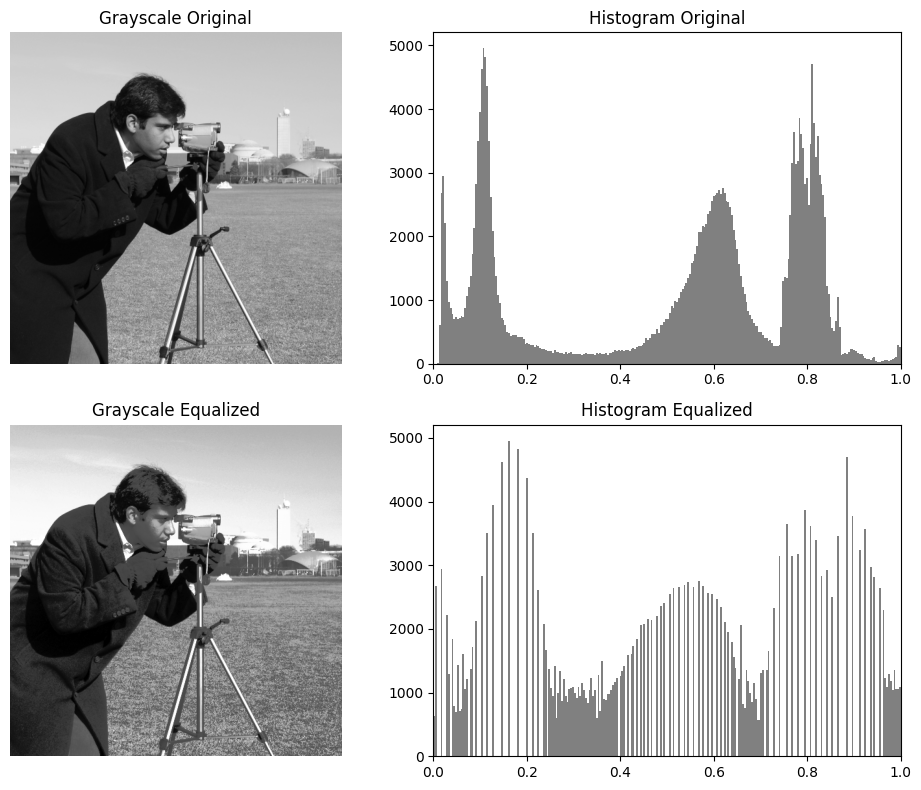

<bound method _AxesBase.set_xlim of <Axes: title={'center': 'Histogram Equalized (RGB)'}>>

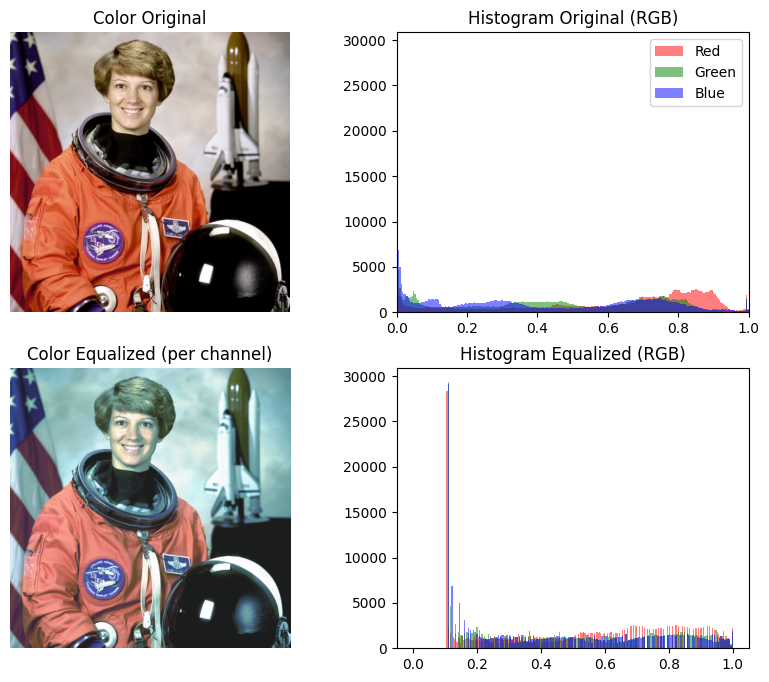

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, exposure, img_as_float

#
# BAGIAN 1: HISTOGRAM & EKUALISASI HISTOGRAM (GRAYSCALE)
#

# 1. Memuat citra grayscale
image_gray_uint8 = data.camera()  # sudah grayscale (uint8, 0..255)
image_gray = img_as_float(image_gray_uint8)  # konversi ke float [0..1]

# 2. Menghitung histogram citra asli (dengan numpy.histogram)
#   Kita perbesar bins=256 untuk melihat distribusi piksel
hist_gray, bins_gray = np.histogram(image_gray.ravel(), bins=256, range=(0, 1))

# 3. Ekualisasi histogram
#   Dengan skimage.exposure.equalize_hist, hasil di rentang [0..1]
image_gray_eq = exposure.equalize_hist(image_gray)
hist_gray_eq, bins_gray_eq = np.histogram(image_gray_eq.ravel(), bins=256, range=(0, 1))

# 4. Plot grayscale: citra asli & histogram, citra ekualisasi & histogram
fig, axes = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra Asli Grayscale
axes[0, 0].imshow(image_gray, cmap='gray')
axes[0, 0].set_title("Grayscale Original")
axes[0, 0].axis('off')

# (b) Histogram Citra Asli
axes[0, 1].hist(image_gray.ravel(), bins=256, range=(0, 1), color='gray')
axes[0, 1].set_title("Histogram Original")
axes[0, 1].set_xlim(0, 1)

# (c) Citra Hasil Ekualisasi
axes[1, 0].imshow(image_gray_eq, cmap='gray')
axes[1, 0].set_title("Grayscale Equalized")
axes[1, 0].axis('off')

# (d) Histogram Citra Hasil Ekualisasi
axes[1, 1].hist(image_gray_eq.ravel(), bins=256, range=(0, 1), color='gray')
axes[1, 1].set_title("Histogram Equalized")
axes[1, 1].set_xlim(0, 1)

plt.tight_layout()
plt.show()

#
# BAGIAN 2: HISTOGRAM & EKUALISASI HISTOGRAM (CITRA WARNA)
#

# 1. Memuat citra berwarna
image_color_uint8 = data.astronaut()  # citra berwarna RGB (uint8)
image_color = img_as_float(image_color_uint8)  # konversi ke float [0..1]

# 2. Kita dapat menghitung histogram gabungan (semua kanal) atau per kanal
#   Di sini kita tampilkan histogram gabungan R, G, B untuk citra asli.
r_channel = image_color[:, :, 0]
g_channel = image_color[:, :, 1]
b_channel = image_color[:, :, 2]

# Hitung histogram untuk tiap kanal, 256 bins
hist_r, bins_r = np.histogram(r_channel.ravel(), bins=256, range=(0, 1))
hist_g, bins_g = np.histogram(g_channel.ravel(), bins=256, range=(0, 1))
hist_b, bins_b = np.histogram(b_channel.ravel(), bins=256, range=(0, 1))

# 3. Ekualisasi histogram tiap kanal secara independen
#   (Catatan: cara ini bisa mengubah keseimbangan warna.
#   Terkadang lebih baik melakukan ekualisasi hanya pada kanal luminance (Y)
#   atau Value (HSV). Tapi di sini kita tunjukkan contoh per kanal.)
r_eq = exposure.equalize_hist(r_channel)
g_eq = exposure.equalize_hist(g_channel)
b_eq = exposure.equalize_hist(b_channel)

# Gabungkan kembali menjadi citra RGB yang sudah di-ekualisasi
image_color_eq = np.dstack((r_eq, g_eq, b_eq))

# Hitung histogram citra berwarna ekualisasi (tiap kanal)
hist_r_eq, bins_r_eq = np.histogram(r_eq.ravel(), bins=256, range=(0, 1))
hist_g_eq, bins_g_eq = np.histogram(g_eq.ravel(), bins=256, range=(0, 1))
hist_b_eq, bins_b_eq = np.histogram(b_eq.ravel(), bins=256, range=(0, 1))

# 4. Plot citra berwarna & histogram
fig2, axes2 = plt.subplots(2, 2, figsize=(10, 8))

# (a) Citra Asli (Color)
axes2[0, 0].imshow(image_color)
axes2[0, 0].set_title("Color Original")
axes2[0, 0].axis('off')

# (b) Histogram Asli (tumpuk R, G, B)
axes2[0, 1].hist(r_channel.ravel(), bins=256, range=(0, 1), color='red', alpha=0.5, label='Red')
axes2[0, 1].hist(g_channel.ravel(), bins=256, range=(0, 1), color='green', alpha=0.5, label='Green')
axes2[0, 1].hist(b_channel.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.5, label='Blue')
axes2[0, 1].set_title("Histogram Original (RGB)")
axes2[0, 1].set_xlim(0, 1)
axes2[0, 1].legend(loc='upper right')

# (c) Citra Hasil Ekualisasi (RGB)
axes2[1, 0].imshow(image_color_eq)
axes2[1, 0].set_title("Color Equalized (per channel)")
axes2[1, 0].axis('off')

# (d) Histogram Ekualisasi (tumpuk R, G, B)
axes2[1, 1].hist(r_eq.ravel(), bins=256, range=(0, 1), color='red', alpha=0.5, label='Red eq')
axes2[1, 1].hist(g_eq.ravel(), bins=256, range=(0, 1), color='green', alpha=0.5, label='Green eq')
axes2[1, 1].hist(b_eq.ravel(), bins=256, range=(0, 1), color='blue', alpha=0.5, label='Blue eq')
axes2[1, 1].set_title("Histogram Equalized (RGB)")
axes2[1, 1].set_xlim

### Praktikum 3. Konvolusi (Filter Rata-rata)

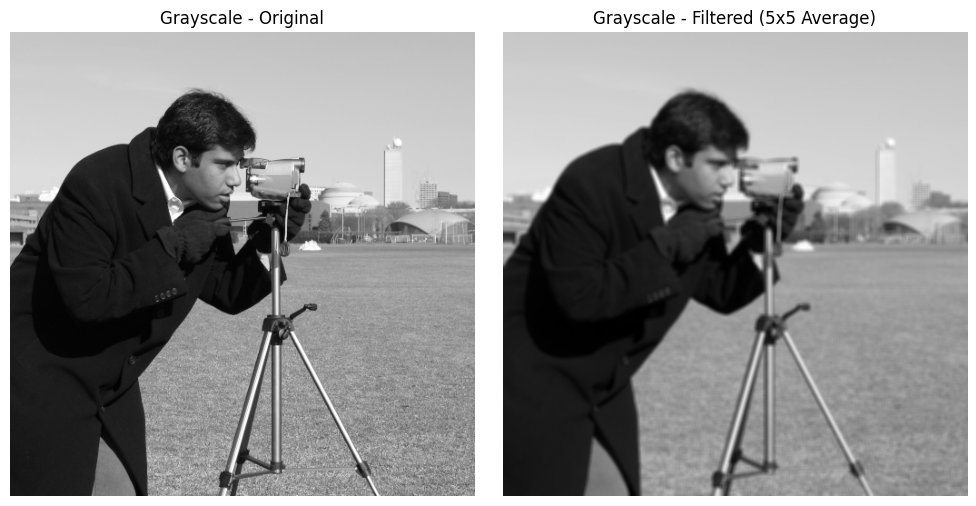

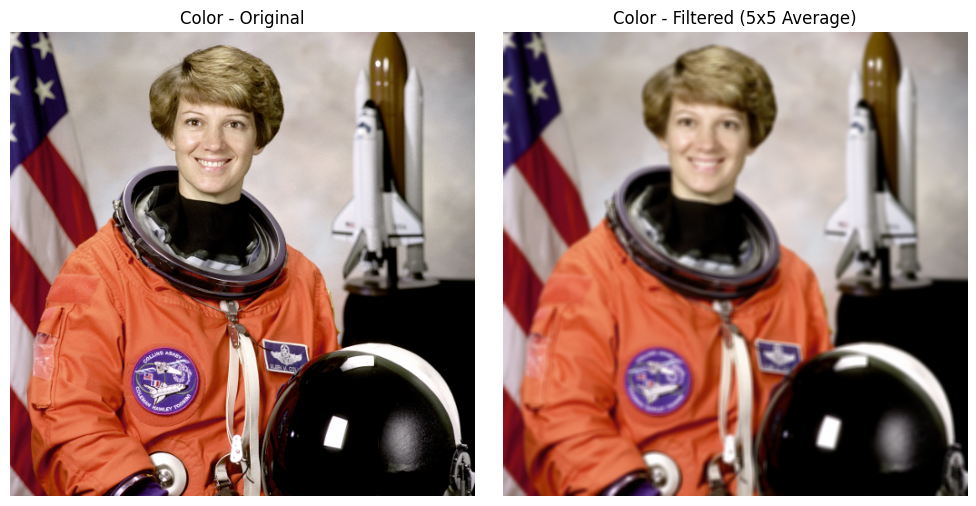

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from scipy import ndimage as ndi

#
# 1) FILTER RATA-RATA PADA CITRA GRAYSCALE
#

# A. Memuat citra grayscale (camera)
gray_uint8 = data.camera()  # range 0..255
gray_img = img_as_float(gray_uint8)  # konversi menjadi float [0..1] untuk kemudahan

# B. Definisikan kernel filter rata-rata (contoh: 5x5)
kernel_size = 5
kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)

# C. Lakukan konvolusi pada citra grayscale
gray_filtered = ndi.convolve(gray_img, kernel, mode='reflect')

# D. Tampilkan hasil
fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(gray_img, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_filtered, cmap='gray')
axes[1].set_title(f"Grayscale - Filtered ({kernel_size}x{kernel_size} Average)")
axes[1].axis('off')

plt.tight_layout()
plt.show()

#
# 2) FILTER RATA-RATA PADA CITRA BERWARNA
#

# A. Memuat citra berwarna (astronaut)
color_uint8 = data.astronaut()  # citra RGB (uint8, 0..255)
color_img = img_as_float(color_uint8)  # konversi float [0..1]

# B. Kita akan terapkan filter rata-rata pada tiap kanal R, G, B
#    secara terpisah, lalu gabungkan.
color_filtered = np.zeros_like(color_img)

for c in range(3):  # c = 0 (Red), 1 (Green), 2 (Blue)
    channel_original = color_img[:, :, c]
    channel_filtered = ndi.convolve(channel_original, kernel, mode='reflect')
    color_filtered[:, :, c] = channel_filtered

# C. Tampilkan hasil
fig2, axes2 = plt.subplots(1, 2, figsize=(10, 5))
axes2[0].imshow(color_img)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_filtered)
axes2[1].set_title(f"Color - Filtered ({kernel_size}x{kernel_size} Average)")
axes2[1].axis('off')

plt.tight_layout()
plt.show()


### Praktikum 4. Filter Median (penghilangan noise/derau)

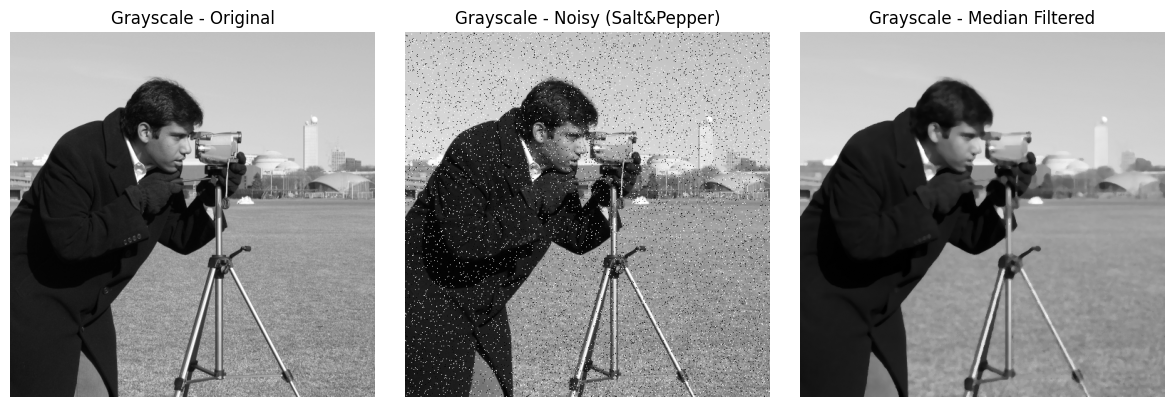

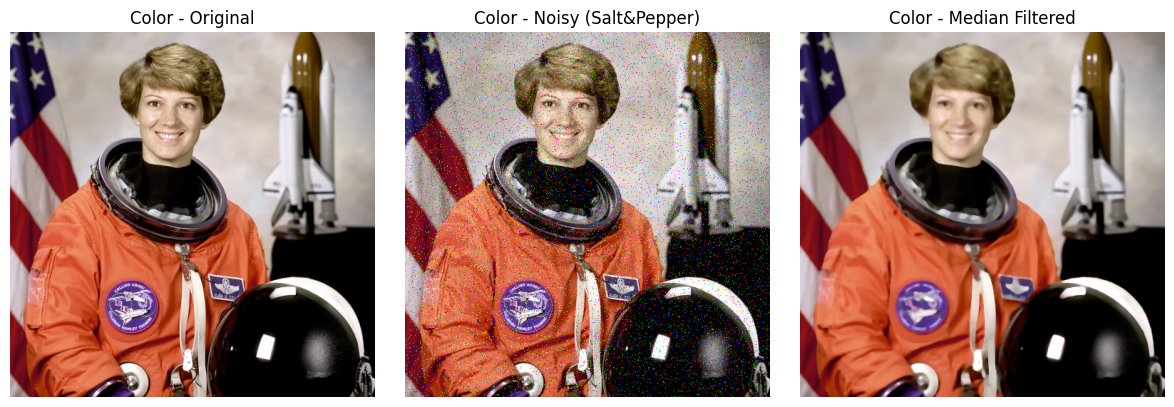

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, filters, morphology, img_as_float

#
# 1) FILTER MEDIAN PADA CITRA GRAYSCALE
#

# A. Memuat citra grayscale (contoh: 'camera')
gray_uint8 = data.camera()  # grayscale, uint8
gray_float = img_as_float(gray_uint8)  # konversi float [0..1]

# B. Menambahkan noise jenis salt-and-pepper
gray_noisy = util.random_noise(gray_float, mode='s&p', amount=0.05)  # amount=0.05 berarti 5% piksel terpengaruh noise

# C. Menerapkan filter median
#    Kita gunakan structuring element berbentuk disk radius 3
disk3 = morphology.disk(3)
gray_denoised = filters.median(gray_noisy, disk3)

# D. Plot hasil
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(gray_float, cmap='gray')
axes[0].set_title("Grayscale - Original")
axes[0].axis('off')

axes[1].imshow(gray_noisy, cmap='gray')
axes[1].set_title("Grayscale - Noisy (Salt&Pepper)")
axes[1].axis('off')

axes[2].imshow(gray_denoised, cmap='gray')
axes[2].set_title("Grayscale - Median Filtered")
axes[2].axis('off')

plt.tight_layout()
plt.show()

#
# 2) FILTER MEDIAN PADA CITRA BERWARNA
#

# A. Memuat citra berwarna (contoh: 'astronaut')
color_uint8 = data.astronaut()  # RGB, uint8
color_float = img_as_float(color_uint8)  # rentang [0..1]

# B. Menambahkan noise salt-and-pepper
color_noisy = util.random_noise(color_float, mode='s&p', amount=0.05)

# C. Menerapkan filter median
#    Pada scikit-image 0.19+, median() mampu menangani array 3D (RGB),
#    atau kita bisa memanggil per kanal. Di sini langsung:
color_denoised = np.zeros_like(color_noisy)
for c in range(color_noisy.shape[2]):
    color_denoised[:, :, c] = filters.median(color_noisy[:, :, c], morphology.disk(3))

# D. Plot hasil
fig2, axes2 = plt.subplots(1, 3, figsize=(12, 4))
axes2[0].imshow(color_float)
axes2[0].set_title("Color - Original")
axes2[0].axis('off')

axes2[1].imshow(color_noisy)
axes2[1].set_title("Color - Noisy (Salt&Pepper)")
axes2[1].axis('off')

axes2[2].imshow(color_denoised)
axes2[2].set_title("Color - Median Filtered")
axes2[2].axis('off')

plt.tight_layout()
plt.show()


### Penugasan 1 - Eksperimen Transformasi Intensitas Lain

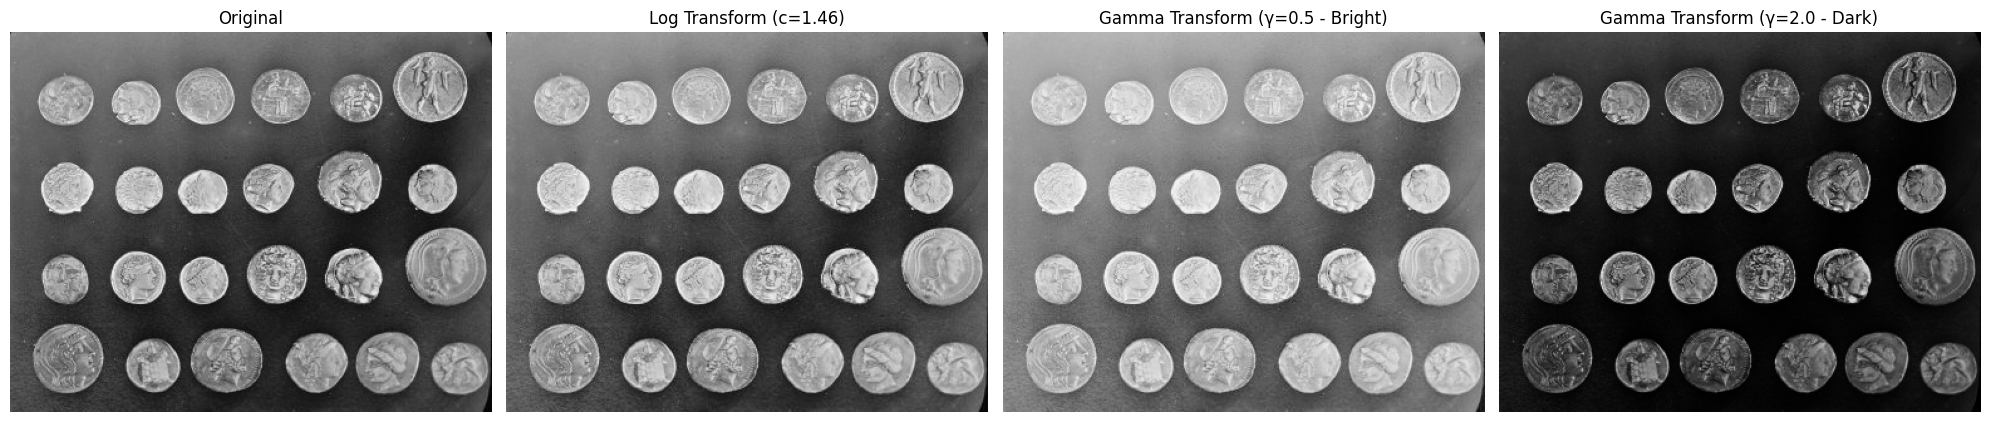

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float
from skimage.color import rgb2gray
import math

# Ambil citra grayscale dari data.coins()
image = data.coins()
image_float = img_as_float(image)  # Konversi ke [0..1]

# ===================
# Transformasi Logaritmik
# ===================
c_log = 1 / np.log(1 + np.max(image_float))
log_transform = c_log * np.log(1 + image_float)

# ===================
# Transformasi Gamma (contoh dengan gamma = 0.5 dan 2.0)
# ===================
gamma_1 = 0.5  # Cerah
gamma_2 = 2.0  # Gelap

gamma_bright = image_float ** gamma_1
gamma_dark = image_float ** gamma_2

# ===================
# Plot hasil
# ===================
fig, axes = plt.subplots(1, 4, figsize=(20, 5))

axes[0].imshow(image_float, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(log_transform, cmap='gray')
axes[1].set_title(f"Log Transform (c={c_log:.2f})")
axes[1].axis('off')

axes[2].imshow(gamma_bright, cmap='gray')
axes[2].set_title("Gamma Transform (γ=0.5 - Bright)")
axes[2].axis('off')

axes[3].imshow(gamma_dark, cmap='gray')
axes[3].set_title("Gamma Transform (γ=2.0 - Dark)")
axes[3].axis('off')

plt.tight_layout()
plt.show()


### Penugasan 2 - Perbandingan Metode Peningkatan Kontras

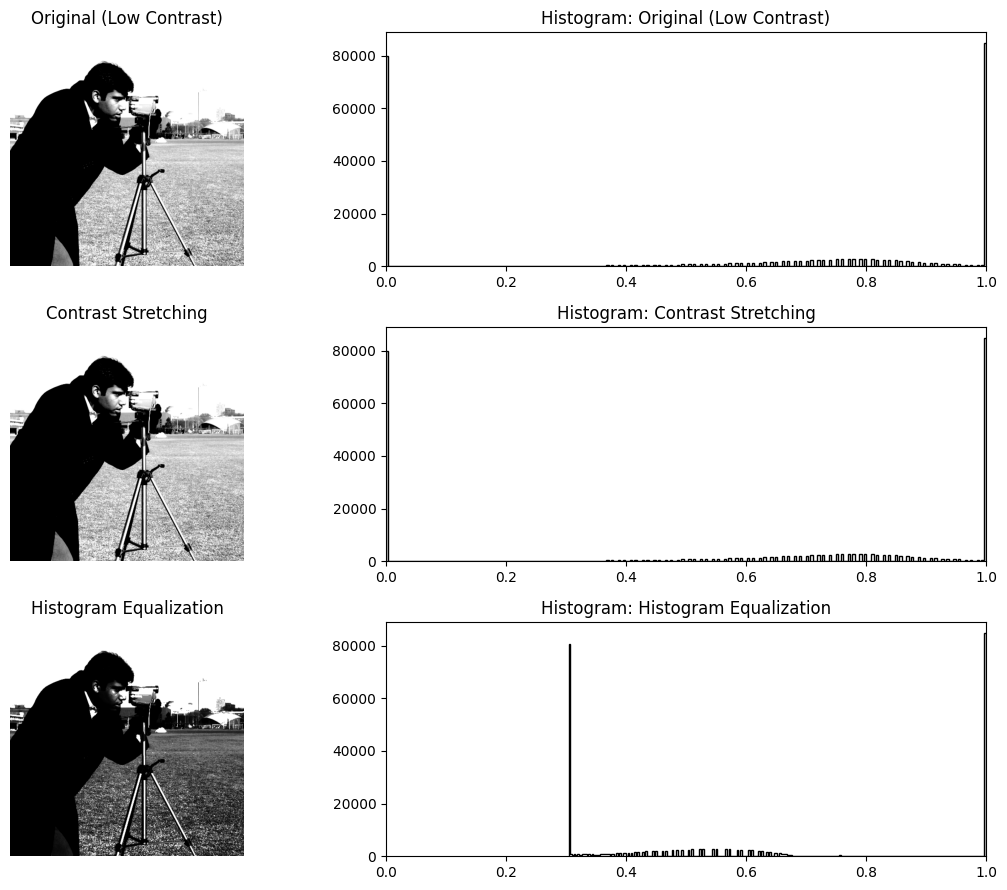

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, img_as_float, exposure, color

# 1. Memuat citra grayscale dengan kontras rendah
# Kita ambil 'camera' dan secara artifisial turunkan kontrasnya untuk uji coba
img = img_as_float(data.camera())  # asli
low_contrast = exposure.rescale_intensity(img, in_range=(0.3, 0.7))  # turunkan kontras

# 2. Peningkatan Kontras

# A. Metode 1: Contrast Stretching
contrast_stretched = exposure.rescale_intensity(low_contrast, in_range='image', out_range=(0, 1))

# B. Metode 2: Histogram Equalization
hist_equalized = exposure.equalize_hist(low_contrast)

# 3. Menampilkan hasil dan histogram
fig, axes = plt.subplots(3, 2, figsize=(12, 9))

titles = ['Original (Low Contrast)', 'Contrast Stretching', 'Histogram Equalization']
images = [low_contrast, contrast_stretched, hist_equalized]

for i, ax in enumerate(axes):
    # Tampilkan gambar
    ax[0].imshow(images[i], cmap='gray')
    ax[0].set_title(titles[i])
    ax[0].axis('off')

    # Histogram
    ax[1].hist(images[i].ravel(), bins=256, histtype='step', color='black')
    ax[1].set_xlim(0, 1)
    ax[1].set_title(f"Histogram: {titles[i]}")

plt.tight_layout()
plt.show()


Penugasan 3 - Filter Median vs Filter Rata-rata

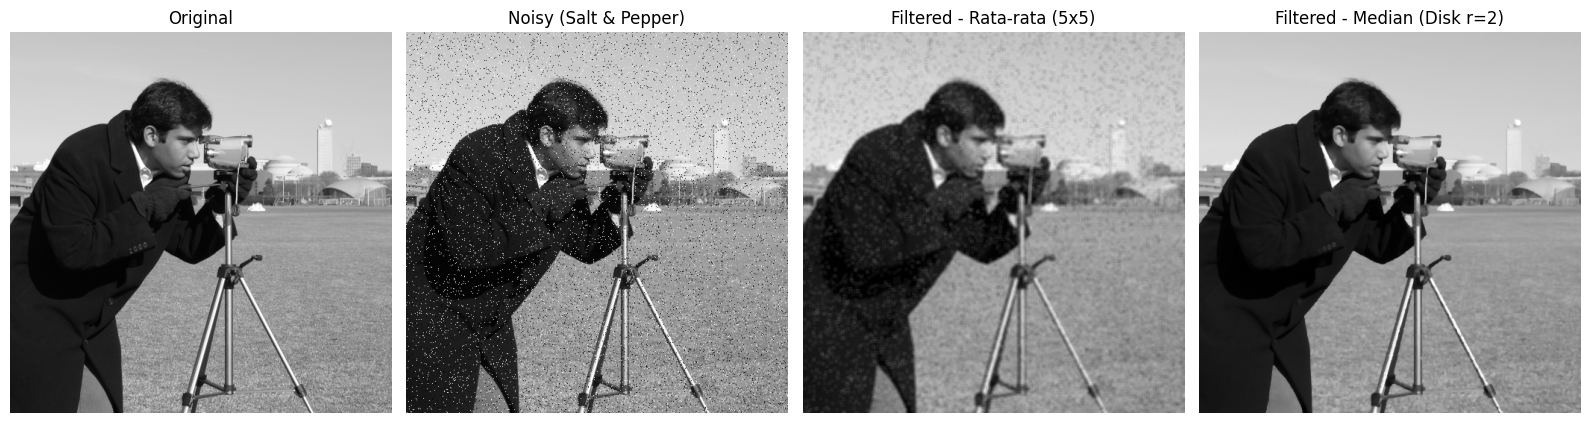

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from skimage import data, util, img_as_float, filters, morphology
from scipy.ndimage import convolve

# 1. Memuat citra grayscale
original_img = img_as_float(data.camera())

# 2. Tambahkan noise salt-and-pepper
noisy_img = util.random_noise(original_img, mode='s&p', amount=0.05)

# 3. Filter Rata-rata (menggunakan kernel 5x5)
kernel_size = 5
avg_kernel = np.ones((kernel_size, kernel_size), dtype=float) / (kernel_size * kernel_size)
avg_filtered = convolve(noisy_img, avg_kernel, mode='reflect')

# 4. Filter Median (menggunakan structuring element disk radius 2)
median_filtered = filters.median(noisy_img, morphology.disk(2))

# 5. Plot hasil
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

axes[0].imshow(original_img, cmap='gray')
axes[0].set_title("Original")
axes[0].axis('off')

axes[1].imshow(noisy_img, cmap='gray')
axes[1].set_title("Noisy (Salt & Pepper)")
axes[1].axis('off')

axes[2].imshow(avg_filtered, cmap='gray')
axes[2].set_title("Filtered - Rata-rata (5x5)")
axes[2].axis('off')

axes[3].imshow(median_filtered, cmap='gray')
axes[3].set_title("Filtered - Median (Disk r=2)")
axes[3].axis('off')

plt.tight_layout()
plt.show()
